<>:311: SyntaxWarning: invalid escape sequence '\g'
<>:331: SyntaxWarning: invalid escape sequence '\g'
<>:347: SyntaxWarning: invalid escape sequence '\g'
<>:311: SyntaxWarning: invalid escape sequence '\g'
<>:331: SyntaxWarning: invalid escape sequence '\g'
<>:347: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_510599/3261223426.py:311: SyntaxWarning: invalid escape sequence '\g'
  plt.title("Fig. 3c — Lindblad master equation (QuTiP), device D5,  no $\gamma_y$, $\gamma_t$")
/tmp/ipykernel_510599/3261223426.py:331: SyntaxWarning: invalid escape sequence '\g'
  plt.title(f"Stored energy & charging power, device D5 (N={N:.1e}), no $\gamma_y$, $\gamma_t$")
/tmp/ipykernel_510599/3261223426.py:347: SyntaxWarning: invalid escape sequence '\g'
  plt.title(f"Ergotropy of the battery subsystem, device D5 (N={N:.1e}),  no $\gamma_y$, $\gamma_t$")


laser nu = 1.6771 eV (lower polariton),  G = 111.8 meV
max S1^0 = 0.0729,  max S1^1 = 0.0118,  T1(4 ps) = 0.0867,  max <n>/molecule = 0.059
max stored energy per molecule   = 168.184 meV at t = 0.135 ps
max stored energy, whole ensemble (N=5.00e+10) = 1.3473e-09 J (8.4092e+09 eV)
peak instantaneous charging power, whole ensemble = 4.6929e+04 W
peak instantaneous charging power, per molecule   = 9.3858e-07 W
average charging power, whole ensemble (0 -> 0.135 ps) = 9.9800e+03 W
average charging power, per molecule   (0 -> 0.135 ps) = 1.9960e-07 W
max ergotropy per molecule        = 124.255 meV at t = 0.125 ps
max ergotropy, whole ensemble     = 9.9540e-10 J
ergotropy / stored energy at peak stored energy (t=0.135 ps) = 68.2%
ergotropy / stored energy at final time         (t=4.000 ps) = 17.4%
Saved stored-energy / charging-power / ergotropy data to fig3c_energy_power.npz / .csv
saved fig3c_qutip.png
Saved CSV to fig3c_qutip_data.csv
saved energy_power_noymyt.png
saved fig3c_ergotropy_noy

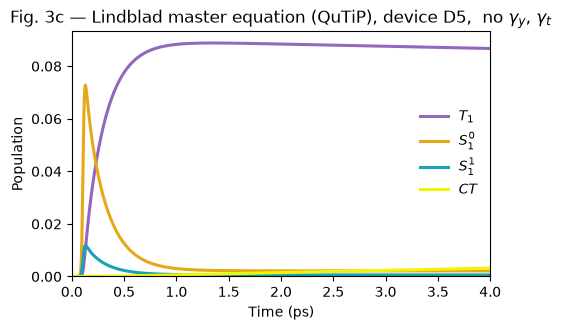

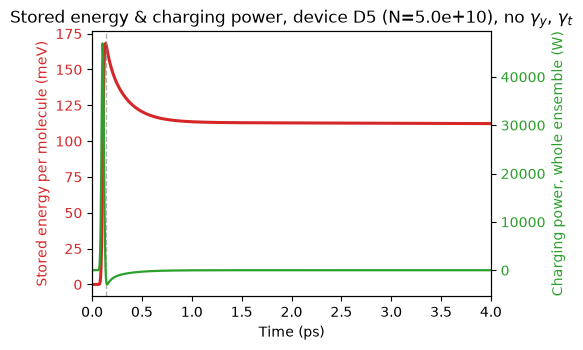

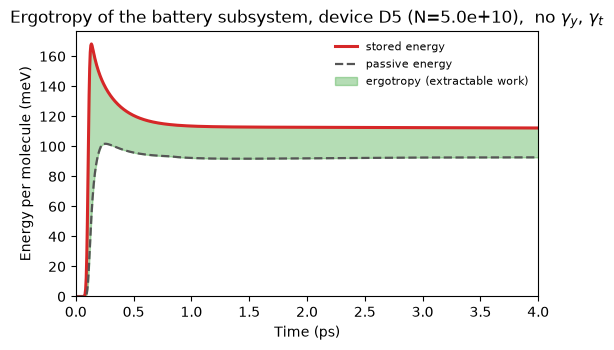

In [2]:
"""
Reproduction of Fig. 3c of Hymas et al., "Superextensive electrical power from a
quantum battery", Light: Science & Applications 15, 168 (2026)
-------------------------------------------------------------------------------
Version 2: QuTiP (mesolve) solution of the Lindblad master equation.

Model (main text Eqs. (3)-(4), SI Sec. III E):
  Driven Tavis-Cummings Hamiltonian, in the rotating frame of the laser, for
  N four-level CuPc molecules {S0=|0>, S1^0=|1>, S1^1=|2>, T1=|T>} coupled to
  one cavity mode, with Lindblad dissipators for cavity loss (kappa), singlet
  non-radiative decay (gamma^-), triplet decay (gamma_T^-), singlet dephasing
  (gamma^z), and intersystem crossing (gamma_ISC).

How the N ~ 5e10 ensemble is made tractable for an exact solver
---------------------------------------------------------------
The exact Hilbert space of Eq. (3) is unreachable for any numerically exact
solver (the authors close a cumulant hierarchy with O(1/N) errors, SI Eq.
(11)).  We therefore use the standard, controlled large-N / weak-excitation
(Holstein-Primakoff) reduction of the driven Tavis-Cummings model.  Fig. 3c
involves per-molecule populations <= 0.08, so corrections to this reduction
are at the few-percent level and vanish in the same N -> infinity limit as
the paper's cumulant closure.

  * The BRIGHT collective transitions B_k = N^{-1/2} sum_j X_{0k}^{(j)}
    (k = 1, 2 for the two Davydov singlets) become bosonic modes b1, b2 that
    carry the full collective coupling G = g*sqrt(N):

      H = (Dc-nu) a^+a + (D1-nu) b1^+b1 + (D2-nu) b2^+b2
          + G [ a^+ (b1 + b2) + (b1^+ + b2^+) a ]  +  i eta_s(t) (a^+ - a).

  * Single-molecule DEPHASING gamma^z (Lindblads L[X11], L[X22] in Eq. (4))
    does two things to the ensemble: it damps the collective optical
    coherence at gamma^z/2, and it scatters excitation out of the bright
    superposition into the N-1 cavity-DECOUPLED dark states at rate gamma^z
    (the dark -> bright return rate is gamma^z/N -> 0).  Both effects are
    captured exactly by the incoherent bright -> dark transfer dissipators
    gamma^z L[d1^+ b1] and gamma^z L[d2^+ b2], where d1, d2 are dark
    reservoir modes.  (Modelling dephasing as pure dephasing L[b^+b] of the
    single bright mode would wrongly keep dephased excitons coupled to the
    leaky cavity; the dark-state protection against superradiant decay is
    essential to the triplet yield, as emphasised in the paper's Discussion.)

  * Intersystem crossing gamma_ISC transfers bright AND dark singlet
    excitation to the triplet reservoir T: dissipators L[T^+ b_k], L[T^+ d_k].
    Singlet decay gamma^- acts on bright and dark modes alike; triplet decay
    gamma_T^- acts on T.

  * Rescaling the drive, eta_s(t) = eta(t)/sqrt(N)
    = sqrt(r/(2 pi sigma^2)) exp(-(t-t0)^2/(2 sigma^2)), makes every mode
    occupation an occupation PER MOLECULE, so that
       <X11> = <b1^+b1> + <d1^+d1>   (S1^0, yellow curve of Fig. 3c)
       <X22> = <b2^+b2> + <d2^+d2>   (S1^1, blue curve)
       <XTT> = <T^+T>                (T1,   purple curve).
    For the linearly driven weak-excitation model this rescaling is exact.

  * Exact gauge choices: the dark and triplet reservoirs enter H only through
    number operators and enter the dissipators only through jump operators,
    which acquire a pure phase under d -> d e^{-i w t}; every Lindblad
    dissipator D[L] is invariant under L -> e^{i phi} L, so their level
    energies (including DT = 1.2 eV) can be set to zero without changing any
    population.  This removes irrelevant THz-scale phase evolution and makes
    the integration fast.  Occupations stay < 0.1 per molecule, so the dark
    and triplet reservoirs are truncated to two levels and the bright/cavity
    modes to small Fock cutoffs.

Parameters: device D5 (SI Tables S1 and S3, main text):
  D1 = 1.80 eV, D2 = 1.98 eV, DT = 1.20 eV, Dc = 1.82 eV,
  g = 500 neV (ultrafast spot), N = 5.0e10  ->  G = g*sqrt(N) ~ 111.8 meV,
  kappa = 29 ps^-1, gamma^- = 0.5 ps^-1, gamma_T^- = 0.01 ps^-1,
  gamma^z = 20 ps^-1, gamma_ISC = 5 ps^-1 (= 1/200 fs),
  Gaussian pulse: sigma = 35/(2 sqrt(2 ln 2)) fs, r = 1/2,
  laser frequency nu tuned to the lower polariton of the device.

Output: fig3c_qutip.png, fig3c_qutip_data.npz
"""

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# ----------------------------- physical constants ---------------------------
hbar = 6.582119569e-4          # eV * ps

# ------------------------- device D5 parameters -----------------------------
Delta1, Delta2, DeltaT, Deltac, DeltaCT = 1.80, 1.98, 1.20, 1.82, 1.0   # eV
g_bare = 500e-9                # eV   [Table S3, ultrafast spot]
N      = 5.0e10                # D5   [Table S3]
G      = g_bare * np.sqrt(N)   # collective coupling (eV)

kappa, gamma_m, gamma_T = 29.0, 0.5, 0.01     # ps^-1  [Table S3, D5]
gamma_z, gamma_ISC      = 20.0, 5.0           # ps^-1

r     = 0.5
sigma = (35.0 / (2*np.sqrt(2*np.log(2)))) * 1e-3   # ps
t0    = 0.10                                       # ps

k_tc      = 0.01      # Triplet -> Charge Transfer
k_rec     = 0.005     # Charge recombination
Gamma_ext = 0.01      # Charge extraction

# ------------- laser tuned to the lower polariton of the device -------------
M_pol = np.array([[Deltac, G,      G     ],
                  [G,      Delta1, 0.0   ],
                  [G,      0.0,    Delta2]])
nu = np.linalg.eigvalsh(M_pol)[0]

# detunings as angular frequencies (rad/ps)
d1, d2, dc = (Delta1-nu)/hbar, (Delta2-nu)/hbar, (Deltac-nu)/hbar
Gw = G / hbar


def build_model():
    """Operators, Hamiltonian, collapse and measurement operators."""
    Na, Nb = 5, 3              # cavity / bright-exciton Fock cutoffs
    Ia, Ib, I2 = qt.qeye(Na), qt.qeye(Nb), qt.qeye(2)

    def emb(op, slot):
        ops = [Ia, Ib, Ib, I2, I2, I2, I2] # a, b1, b2, d1, d2, T, CT
        ops[slot] = op
        return qt.tensor(*ops)

    a  = emb(qt.destroy(Na), 0)            # cavity mode
    b1 = emb(qt.destroy(Nb), 1)            # bright S1^0 exciton
    b2 = emb(qt.destroy(Nb), 2)            # bright S1^1 exciton
    dk1 = emb(qt.destroy(2), 3)            # dark S1^0 reservoir (2-level)
    dk2 = emb(qt.destroy(2), 4)            # dark S1^1 reservoir
    Tm  = emb(qt.destroy(2), 5)            # triplet reservoir (2-level)
    CT = emb(qt.destroy(2), 6)
    H0 = (dc * a.dag()*a + d1 * b1.dag()*b1 + d2 * b2.dag()*b2
          + Gw * (a.dag()*(b1 + b2) + (b1.dag() + b2.dag())*a)
           + DeltaCT * CT.dag()*CT)
    Hdrive = 1j * (a.dag() - a)            # i eta_s(t) (a^+ - a)

    c_ops = [np.sqrt(kappa)     * a,
             np.sqrt(gamma_z)   * dk1.dag()*b1,     # dephasing: bright -> dark
             np.sqrt(gamma_z)   * dk2.dag()*b2,
             np.sqrt(gamma_ISC) * Tm.dag()*b1,      # ISC (bright)
             np.sqrt(gamma_ISC) * Tm.dag()*b2,
             np.sqrt(gamma_ISC) * Tm.dag()*dk1,     # ISC (dark)
             np.sqrt(gamma_ISC) * Tm.dag()*dk2,
             np.sqrt(k_tc)      * CT.dag()*Tm,   # T -> CT
             np.sqrt(k_rec)     * CT,            # CT -> ground (loss)
             np.sqrt(Gamma_ext) * CT]             # CT -> ground (electrical extraction)]

    e_ops = [b1.dag()*b1 + dk1.dag()*dk1,           # <X11>  (S1^0)
             b2.dag()*b2 + dk2.dag()*dk2,           # <X22>  (S1^1)
             Tm.dag()*Tm,                           # <XTT>  (T1)
             CT.dag()*CT,
             a.dag()*a]                             # photons per molecule

    # "Battery" Hamiltonian: the REAL (lab-frame) molecular energies, not the
    # rotating-frame detunings used in H0. The stored energy of the battery
    # (excitons + triplets, measured from the S0 ground state) is a physical
    # quantity and must not depend on the rotating frame chosen for the
    # numerics, so we build it from Delta1, Delta2, DeltaT directly. The
    # cavity/photon energy is deliberately excluded: the cavity is the
    # charger, not the battery.
    H_batt = (Delta1 * (b1.dag()*b1 + dk1.dag()*dk1)
              + Delta2 * (b2.dag()*b2 + dk2.dag()*dk2)
              + DeltaT * Tm.dag()*Tm + DeltaCT * CT.dag()*CT)

    # Battery-ONLY Hamiltonian, with no cavity tensor factor at all. Ergotropy
    # is defined as the work extractable by a unitary acting solely on the
    # battery (b1,b2,dark1,dark2,T), so it needs the reduced state
    # rho_batt = rho.ptrace([1,2,3,4,5]) and this operator's own eigenvalues
    # -- NOT H_batt embedded in the full space, whose spectrum also carries
    # (irrelevant) cavity Fock-number degeneracies.
    Ib2, I22 = qt.qeye(Nb), qt.qeye(2)

    def emb_loc(op, slot):
        ops = [Ib2, Ib2, I22, I22, I22, I22]    # b1, b2, d1, d2, T  (no cavity)
        ops[slot] = op
        return qt.tensor(*ops)

    b1_l, b2_l   = emb_loc(qt.destroy(Nb), 0), emb_loc(qt.destroy(Nb), 1)
    dk1_l, dk2_l = emb_loc(qt.destroy(2), 2), emb_loc(qt.destroy(2), 3)
    Tm_l = emb_loc(qt.destroy(2),4)
    CT_l = emb_loc(qt.destroy(2),5)
    H_batt_loc = (Delta1 * (b1_l.dag()*b1_l + dk1_l.dag()*dk1_l)
                  + Delta2 * (b2_l.dag()*b2_l + dk2_l.dag()*dk2_l)
                  + DeltaT * Tm_l.dag()*Tm_l + DeltaCT * CT_l.dag()*CT_l)

    psi0 = qt.tensor(qt.basis(Na, 0), qt.basis(Nb, 0), qt.basis(Nb, 0),
                     qt.basis(2, 0), qt.basis(2, 0), qt.basis(2, 0),qt.basis(2, 0) )
    return H0, Hdrive, c_ops, e_ops, psi0, H_batt, H_batt_loc


def eta_s(t):
    """Rescaled pulse envelope eta(t)/sqrt(N) (rad/ps)."""
    return np.sqrt(r / (2*np.pi*sigma**2)) * np.exp(-(t - t0)**2 / (2*sigma**2))


print(f"laser nu = {nu:.4f} eV (lower polariton),  G = {G*1e3:.1f} meV")
H0, Hdrive, c_ops, e_ops, psi0, H_batt, H_batt_loc = build_model()
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000, "store_states": True})

P_S10, P_S11, P_T1, P_CT, n_ph = (
    np.real(res.expect[k]) for k in range(5)
)
np.savez("population-res-noymyt.npz", t=tlist,
            S10=P_S10, S11=P_S11, T1=P_T1, CT=P_CT)

print(f"max S1^0 = {P_S10.max():.4f},  max S1^1 = {P_S11.max():.4f},  "
        f"T1(4 ps) = {P_T1[-1]:.4f},  max <n>/molecule = {n_ph.max():.3f}")

# ------------------- stored energy and charging power ----------------------
# Stored energy is computed as the explicit trace  E(t) = Tr[ rho(t) H_batt ]
# for every state returned by mesolve (available because store_states=True),
# rather than being reconstructed from the e_ops populations. This is the
# textbook definition of the ergotropy-free "stored energy" of a battery: the
# expectation value of the battery's own Hamiltonian, H_batt, which uses the
# real (lab-frame) molecular energies Delta1, Delta2, DeltaT -- see build_model().
eV_to_J = 1.602176634e-19          # J per eV
ps_to_s = 1e-12                    # s per ps

E_per_molecule = np.array([(H_batt * rho).tr().real for rho in res.states])  # eV, per molecule
E_total_eV     = N * E_per_molecule            # eV,  whole N-molecule ensemble
E_total_J      = E_total_eV * eV_to_J          # J,   whole ensemble

# Charging power = time derivative of the stored energy (instantaneous power).
P_inst_per_mol_W = np.gradient(E_per_molecule * eV_to_J, tlist * ps_to_s)   # W / molecule
P_inst_total_W   = np.gradient(E_total_J,               tlist * ps_to_s)   # W, whole ensemble

# Average charging power up to the moment of peak stored energy, the usual
# quantum-battery figure of merit  P_avg = E_max / tau_charge.
i_peak     = int(np.argmax(E_per_molecule))
tau_charge = tlist[i_peak] * ps_to_s            # s
P_avg_per_mol_W = (E_per_molecule[i_peak] * eV_to_J) / tau_charge if tau_charge > 0 else np.nan
P_avg_total_W   = E_total_J[i_peak]             / tau_charge if tau_charge > 0 else np.nan

print(f"max stored energy per molecule   = {E_per_molecule[i_peak]*1e3:.3f} meV "
        f"at t = {tlist[i_peak]:.3f} ps")
print(f"max stored energy, whole ensemble (N={N:.2e}) = {E_total_J[i_peak]:.4e} J "
        f"({E_total_eV[i_peak]:.4e} eV)")
print(f"peak instantaneous charging power, whole ensemble = {P_inst_total_W.max():.4e} W")
print(f"peak instantaneous charging power, per molecule   = {P_inst_per_mol_W.max():.4e} W")
print(f"average charging power, whole ensemble (0 -> {tlist[i_peak]:.3f} ps) = {P_avg_total_W:.4e} W")
print(f"average charging power, per molecule   (0 -> {tlist[i_peak]:.3f} ps) = {P_avg_per_mol_W:.4e} W")

# ------------------------- ergotropy (extractable work) ---------------------
# Ergotropy is the maximum work extractable from the battery by a UNITARY
# acting only on the battery's own Hilbert space (b1,b2,dark1,dark2,T) -- the
# cavity/charger is excluded, exactly as for H_batt above. It is defined as
#     W(t) = Tr[rho_batt(t) H_batt_loc] - E_passive(t)
# where the "passive" state is the energy-minimising state reachable from
# rho_batt(t) by such a unitary: it has the SAME eigenvalues as rho_batt(t),
# reassigned to the eigenbasis of H_batt_loc by the rearrangement inequality
# (largest population <-> smallest energy level, next-largest <-> next-
# smallest, ...). We get rho_batt(t) via an explicit partial trace over the
# cavity mode (qutip's .ptrace), and diagonalize both operators explicitly.
eps_batt = np.sort(H_batt_loc.eigenenergies())      # eV, ascending: battery energy levels
eps_batt = np.clip(eps_batt, 0.0, None)             # exact by construction; clip guards float noise

E_passive_per_molecule = np.zeros_like(tlist)
for i, rho in enumerate(res.states):
    rho_batt = rho.ptrace([1,2,3,4,5,6])         # trace OUT the cavity (index 0)
    r_k = np.sort(rho_batt.eigenenergies())[::-1]   # populations, descending
    r_k = np.clip(r_k, 0.0, None)                   # density-matrix eigenvalues can't be < 0;
    r_k = r_k / r_k.sum()                           # tiny negatives here are solver-tolerance noise
    E_passive_per_molecule[i] = np.sum(r_k * eps_batt)   # rearrangement-inequality pairing

# Guard against ~1e-12-level numerical noise pushing ergotropy fractionally below 0.
Ergotropy_per_molecule = np.clip(E_per_molecule - E_passive_per_molecule, 0.0, None)  # eV/molecule
Ergotropy_total_eV = N * Ergotropy_per_molecule
Ergotropy_total_J  = Ergotropy_total_eV * eV_to_J

# Fraction of the stored energy that is actually extractable as work.
ergo_frac = np.divide(Ergotropy_per_molecule, E_per_molecule,
                       out=np.zeros_like(E_per_molecule), where=E_per_molecule > 1e-12)
i_ergo_peak = int(np.argmax(Ergotropy_per_molecule))

print(f"max ergotropy per molecule        = {Ergotropy_per_molecule[i_ergo_peak]*1e3:.3f} meV "
        f"at t = {tlist[i_ergo_peak]:.3f} ps")
print(f"max ergotropy, whole ensemble     = {Ergotropy_total_J[i_ergo_peak]:.4e} J")
print(f"ergotropy / stored energy at peak stored energy (t={tlist[i_peak]:.3f} ps) = "
        f"{ergo_frac[i_peak]*100:.1f}%")
print(f"ergotropy / stored energy at final time         (t={tlist[-1]:.3f} ps) = "
        f"{ergo_frac[-1]*100:.1f}%")

np.savez("energy_power_noymyt.npz", t=tlist,
            E_per_molecule_eV=E_per_molecule, E_total_eV=E_total_eV, E_total_J=E_total_J,
            P_inst_total_W=P_inst_total_W, P_inst_per_mol_W=P_inst_per_mol_W,
            tau_charge_s=tau_charge, P_avg_total_W=P_avg_total_W, P_avg_per_mol_W=P_avg_per_mol_W,
            E_passive_per_molecule_eV=E_passive_per_molecule,
            Ergotropy_per_molecule_eV=Ergotropy_per_molecule,
            Ergotropy_total_eV=Ergotropy_total_eV, Ergotropy_total_J=Ergotropy_total_J)
np.savetxt('energy_power_noymyt.csv',
            np.column_stack((tlist, E_per_molecule, E_total_eV, E_total_J,
                              P_inst_per_mol_W, P_inst_total_W,
                              E_passive_per_molecule, Ergotropy_per_molecule, Ergotropy_total_J)),
            delimiter=',',
            header='t_ps,E_per_molecule_eV,E_total_eV,E_total_J,P_inst_per_mol_W,P_inst_total_W,'
                   'E_passive_per_molecule_eV,Ergotropy_per_molecule_eV,Ergotropy_total_J',
            comments='')
print('Saved stored-energy / charging-power / ergotropy data to fig3c_energy_power.npz / .csv')

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.plot(tlist, P_CT, color="#f1f505", lw=2.2, label=r"$CT$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title("Fig. 3c — Lindblad master equation (QuTiP), device D5,  no $\gamma_y$, $\gamma_t$")
plt.tight_layout()
plt.savefig("fig3c_qutip_noymyt.png", dpi=200)
print("saved fig3c_qutip.png")
np.savetxt('population-res-noymyt.csv', np.column_stack((tlist, P_S10, P_S11, P_T1)), delimiter=',', header='t,S10,S11,T1', comments='')
print('Saved CSV to fig3c_qutip_data.csv')

fig, ax1 = plt.subplots(figsize=(5.6, 3.6))
ax1.plot(tlist, E_per_molecule*1e3, color="#d62728", lw=2.2)
ax1.set_xlabel("Time (ps)")
ax1.set_ylabel("Stored energy per molecule (meV)", color="#d62728")
ax1.tick_params(axis='y', labelcolor="#d62728")
ax1.set_xlim(0, 4)
ax1.axvline(tlist[i_peak], color='gray', ls='--', lw=1, alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(tlist, P_inst_total_W, color="#2ca02c", lw=1.6)
ax2.set_ylabel("Charging power, whole ensemble (W)", color="#2ca02c")
ax2.tick_params(axis='y', labelcolor="#2ca02c")

plt.title(f"Stored energy & charging power, device D5 (N={N:.1e}), no $\gamma_y$, $\gamma_t$")
fig.tight_layout()
plt.savefig("energy_power_noymyt.png", dpi=200)
print("saved energy_power_noymyt.png")

plt.figure(figsize=(5.6, 3.6))
plt.plot(tlist, E_per_molecule*1e3, color="#d62728", lw=2.2, label="stored energy")
plt.plot(tlist, E_passive_per_molecule*1e3, color="#555555", lw=1.6, ls="--",
         label="passive energy")
plt.fill_between(tlist, E_passive_per_molecule*1e3, E_per_molecule*1e3,
                  color="#2ca02c", alpha=0.35, label="ergotropy (extractable work)")
plt.xlabel("Time (ps)")
plt.ylabel("Energy per molecule (meV)")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False, fontsize=8)
plt.title(f"Ergotropy of the battery subsystem, device D5 (N={N:.1e}),  no $\gamma_y$, $\gamma_t$")
plt.tight_layout()
plt.savefig("fig3c_ergotropy_noymyt.png", dpi=200)
print("saved fig3c_ergotropy_noymyt.png")

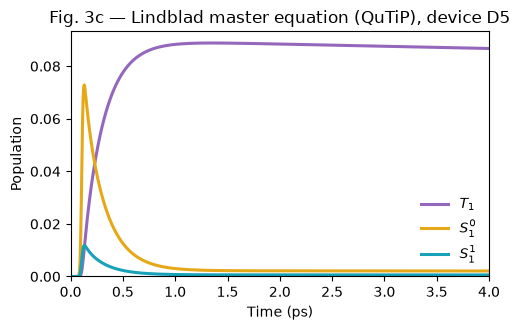

In [3]:
import pandas as pd

qutip_data = np.load('population-res-noymyt.npz')
tlist = qutip_data['t']
P_S10 = qutip_data['S10']
P_S11 = qutip_data['S11']
P_T1 = qutip_data['T1']

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title("Fig. 3c — Lindblad master equation (QuTiP), device D5")
plt.tight_layout()
plt.show()

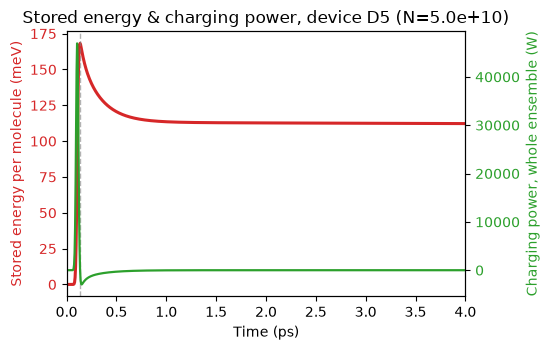

In [4]:
data = np.load("energy_power_noymyt.npz")
tlist = data['t']
E_per_molecule = data['E_per_molecule_eV']
P_inst_total_W = data['P_inst_total_W']

i_peak = int(np.argmax(E_per_molecule))

fig, ax1 = plt.subplots(figsize=(5.6, 3.6))
ax1.plot(tlist, E_per_molecule*1e3, color="#d62728", lw=2.2)
ax1.set_xlabel("Time (ps)")
ax1.set_ylabel("Stored energy per molecule (meV)", color="#d62728")
ax1.tick_params(axis='y', labelcolor="#d62728")
ax1.set_xlim(0, 4)
ax1.axvline(tlist[i_peak], color='gray', ls='--', lw=1, alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(tlist, P_inst_total_W, color="#2ca02c", lw=1.6)
ax2.set_ylabel("Charging power, whole ensemble (W)", color="#2ca02c")
ax2.tick_params(axis='y', labelcolor="#2ca02c")

plt.title("Stored energy & charging power, device D5 (N=5.0e+10)")
fig.tight_layout()
plt.show()

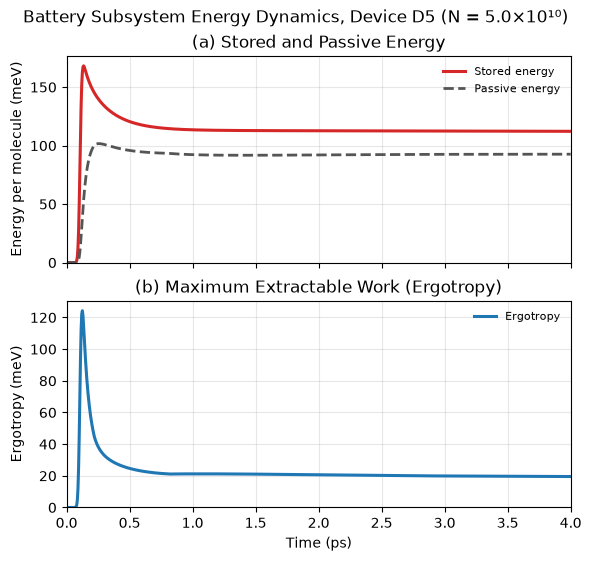

In [5]:
# Load data
data = np.load("energy_power_noymyt.npz")
tlist = data["t"]
E = data["E_per_molecule_eV"] * 1e3          # meV
E_passive = data["E_passive_per_molecule_eV"] * 1e3
ergotropy = E - E_passive

# Create figure
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(5.8, 5.5),
    sharex=True,
    constrained_layout=True
)

# -------------------------
# (a) Stored & Passive Energy
# -------------------------
ax1.plot(tlist, E, color="#d62728", lw=2.2, label="Stored energy")
ax1.plot(
    tlist,
    E_passive,
    color="#555555",
    lw=2.0,
    ls="--",
    label="Passive energy"
)

ax1.set_ylabel("Energy per molecule (meV)")
ax1.set_xlim(0, 4)
ax1.set_ylim(bottom=0)
ax1.set_title("(a) Stored and Passive Energy")
ax1.grid(alpha=0.3)
ax1.legend(frameon=False, fontsize=8)

# -------------------------
# (b) Ergotropy
# -------------------------
ax2.plot(
    tlist,
    ergotropy,
    color="#1f77b4",
    lw=2.2,
    label="Ergotropy"
)

ax2.set_xlabel("Time (ps)")
ax2.set_ylabel("Ergotropy (meV)")
ax2.set_xlim(0, 4)
ax2.set_ylim(bottom=0)
ax2.set_title("(b) Maximum Extractable Work (Ergotropy)")
ax2.grid(alpha=0.3)
ax2.legend(frameon=False, fontsize=8)

# Overall title
fig.suptitle(
    "Battery Subsystem Energy Dynamics, Device D5 (N = 5.0×10¹⁰)",
    fontsize=12
)

plt.show()